# 🧠 BRISC 2025 Dataset - Exploratory Data Analysis

This notebook provides a comprehensive analysis of the BRISC2025 dataset, covering both:
- **Classification Task**: Tumor type classification (Glioma, Meningioma, No Tumor, Pituitary)
- **Segmentation Task**: Tumor localization with pixel-wise masks

## Dataset Citation
```bibtex
@article{fateh2025brisc,
  title={Brisc: Annotated dataset for brain tumor segmentation and classification with swin-hafnet},
  author={Fateh, Amirreza and Rezvani, Yasin and Moayedi, Sara and others},
  journal={arXiv preprint arXiv:2506.14318},
  year={2025}
}
```

## Table of Contents
1. Dataset Overview
2. Classification Task Analysis
3. Segmentation Task Analysis  
4. Data Quality Assessment
5. Recommendations

## 1. Setup & Data Loading

In [22]:
# Imports
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Dataset path
BASE_DIR = "../data/brisc2025"
print(f"✅ Dataset path: {BASE_DIR}")

✅ Dataset path: ../data/brisc2025


## 2. Dataset Structure Overview

In [23]:
def count_files(pattern):
    """Count files matching pattern"""
    return len(glob.glob(pattern))

# Classification task structure
print("="*60)
print("📊 CLASSIFICATION TASK")
print("="*60)

splits = ['train', 'test']
classes = ['glioma', 'meningioma', 'no_tumor', 'pituitary']

cls_data = []
for split in splits:
    split_total = 0
    for cls in classes:
        # Use flexible pattern to match various image extensions
        pattern = os.path.join(BASE_DIR, 'classification_task', split, cls, '*.*g')
        count = count_files(pattern)
        cls_data.append({'Split': split, 'Class': cls, 'Count': count})
        split_total += count
    cls_data.append({'Split': split, 'Class': 'TOTAL', 'Count': split_total})

df_cls = pd.DataFrame(cls_data)
print("\nClassification Distribution:")
display(df_cls.pivot_table(index='Class', columns='Split', values='Count', fill_value=0))

# Segmentation task structure  
print("\n" + "="*60)
print("🎯 SEGMENTATION TASK")
print("="*60)

seg_data = []
for split in splits:
    for data_type in ['images', 'masks']:
        pattern = os.path.join(BASE_DIR, 'segmentation_task', split, data_type, '*')
        count = count_files(pattern)
        seg_data.append({'Split': split, 'Type': data_type, 'Count': count})

df_seg = pd.DataFrame(seg_data)
print("\nSegmentation Distribution:")
display(df_seg.pivot_table(index='Type', columns='Split', values='Count', fill_value=0))

📊 CLASSIFICATION TASK

Classification Distribution:


Split,test,train
Class,,
TOTAL,1000.0,5000.0
glioma,254.0,1147.0
meningioma,306.0,1329.0
no_tumor,140.0,1067.0
pituitary,300.0,1457.0



🎯 SEGMENTATION TASK

Segmentation Distribution:


Split,test,train
Type,,
images,860.0,3933.0
masks,860.0,3933.0


## 3. Classification Task - Detailed Analysis

### 3.1 Class Distribution Visualization

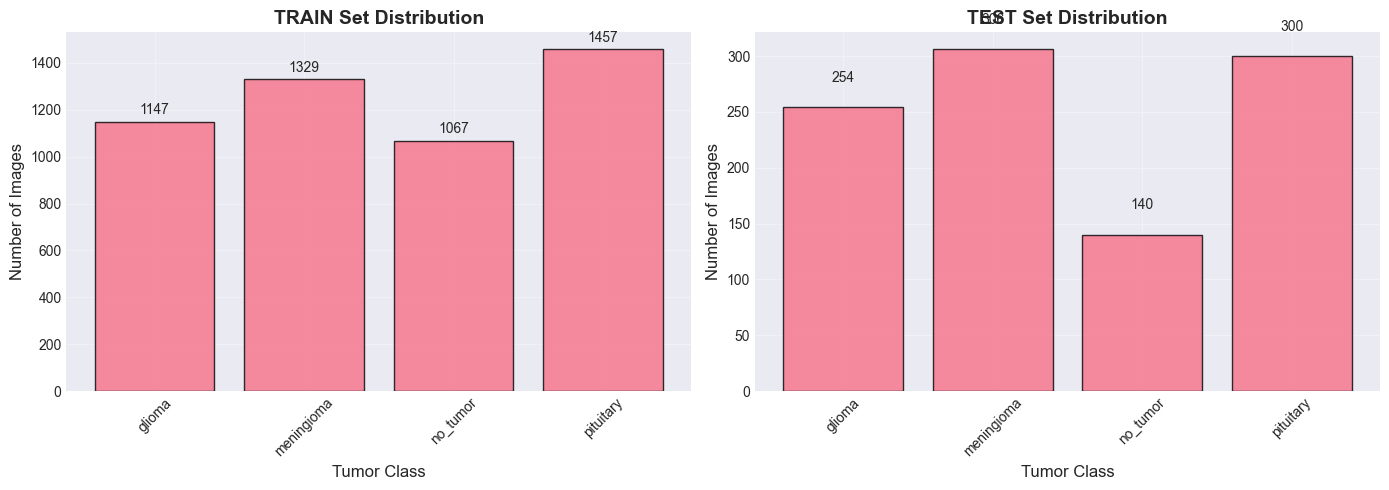

💾 Saved: ../logs/classification/class_distribution.png


In [24]:
# Create output directory if it doesn't exist
os.makedirs('../logs/classification', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, split in enumerate(splits):
    data = df_cls[(df_cls['Split'] == split) & (df_cls['Class'] != 'TOTAL')]
    axes[idx].bar(data['Class'], data['Count'], edgecolor='black', alpha=0.8)
    axes[idx].set_title(f'{split.upper()} Set Distribution', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Tumor Class', fontsize=12)
    axes[idx].set_ylabel('Number of Images', fontsize=12)
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(True, alpha=0.3)
    
    # Add count labels on bars
    for i, (cls, count) in enumerate(zip(data['Class'], data['Count'])):
        axes[idx].text(i, count + 20, str(count), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../logs/classification/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("💾 Saved: ../logs/classification/class_distribution.png")

### 3.2 Anatomical Plane Analysis

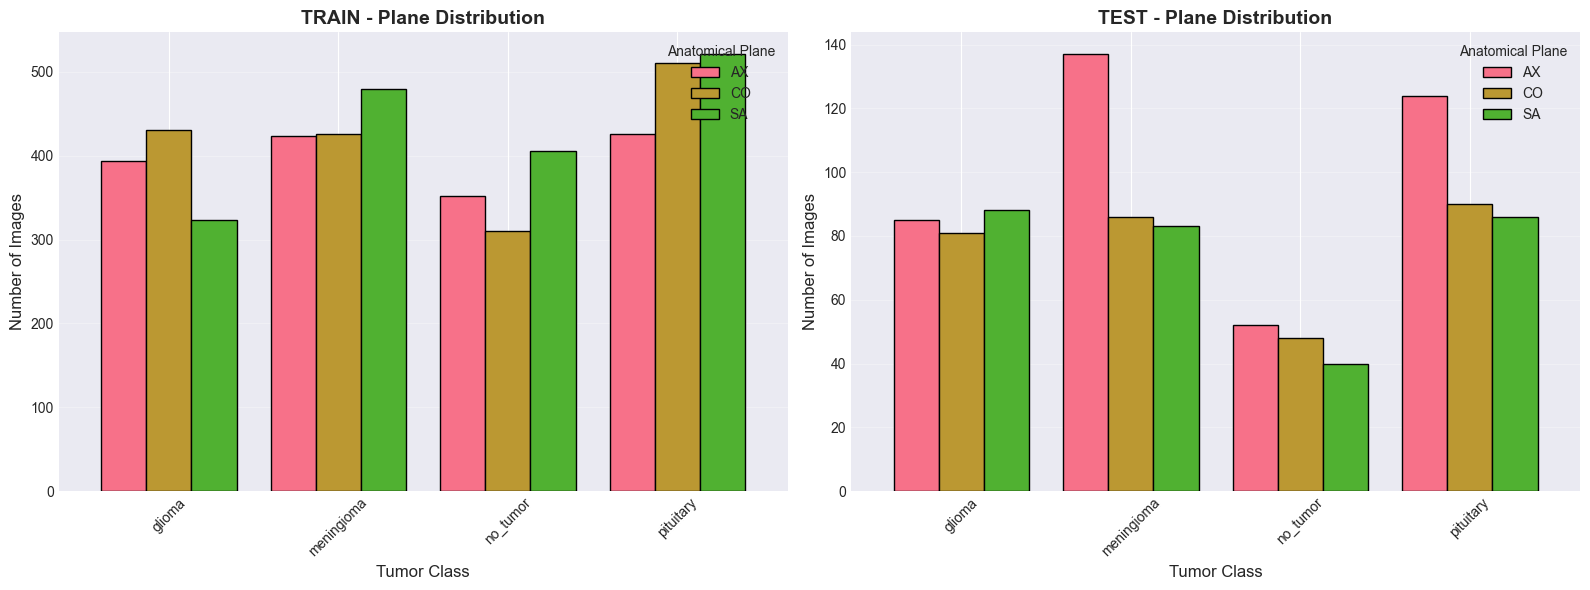


📊 Plane Distribution Summary:


Split   test                                train                      \
Class glioma meningioma no_tumor pituitary glioma meningioma no_tumor   
Plane                                                                   
AX      85.0      137.0     52.0     124.0  394.0      423.0    352.0   
CO      81.0       86.0     48.0      90.0  430.0      426.0    310.0   
SA      88.0       83.0     40.0      86.0  323.0      480.0    405.0   

Split            
Class pituitary  
Plane            
AX        426.0  
CO        510.0  
SA        521.0


💾 Saved: ../logs/classification/plane_distribution.png


In [25]:
# Analyze per anatomical plane
planes = ['ax', 'co', 'sa']  # Axial, Coronal, Sagittal
plane_data = []

for split in splits:
    for cls in classes:
        for plane in planes:
            # Use flexible pattern to match various image extensions
            pattern = os.path.join(BASE_DIR, 'classification_task', split, cls, f'*_{plane}_t1.*g')
            count = count_files(pattern)
            plane_data.append({
                'Split': split,
                'Class': cls,
                'Plane': plane.upper(),
                'Count': count
            })

df_planes = pd.DataFrame(plane_data)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, split in enumerate(splits):
    pivot_data = df_planes[df_planes['Split'] == split].pivot_table(
        index='Class', columns='Plane', values='Count', fill_value=0
    )
    
    pivot_data.plot(kind='bar', ax=axes[idx], width=0.8, edgecolor='black')
    axes[idx].set_title(f'{split.upper()} - Plane Distribution', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Tumor Class', fontsize=12)
    axes[idx].set_ylabel('Number of Images', fontsize=12)
    axes[idx].legend(title='Anatomical Plane', loc='upper right')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../logs/classification/plane_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Plane Distribution Summary:")
display(df_planes.pivot_table(index='Plane', columns=['Split', 'Class'], values='Count'))
print("\n💾 Saved: ../logs/classification/plane_distribution.png")

### 3.3 Sample Images Visualization

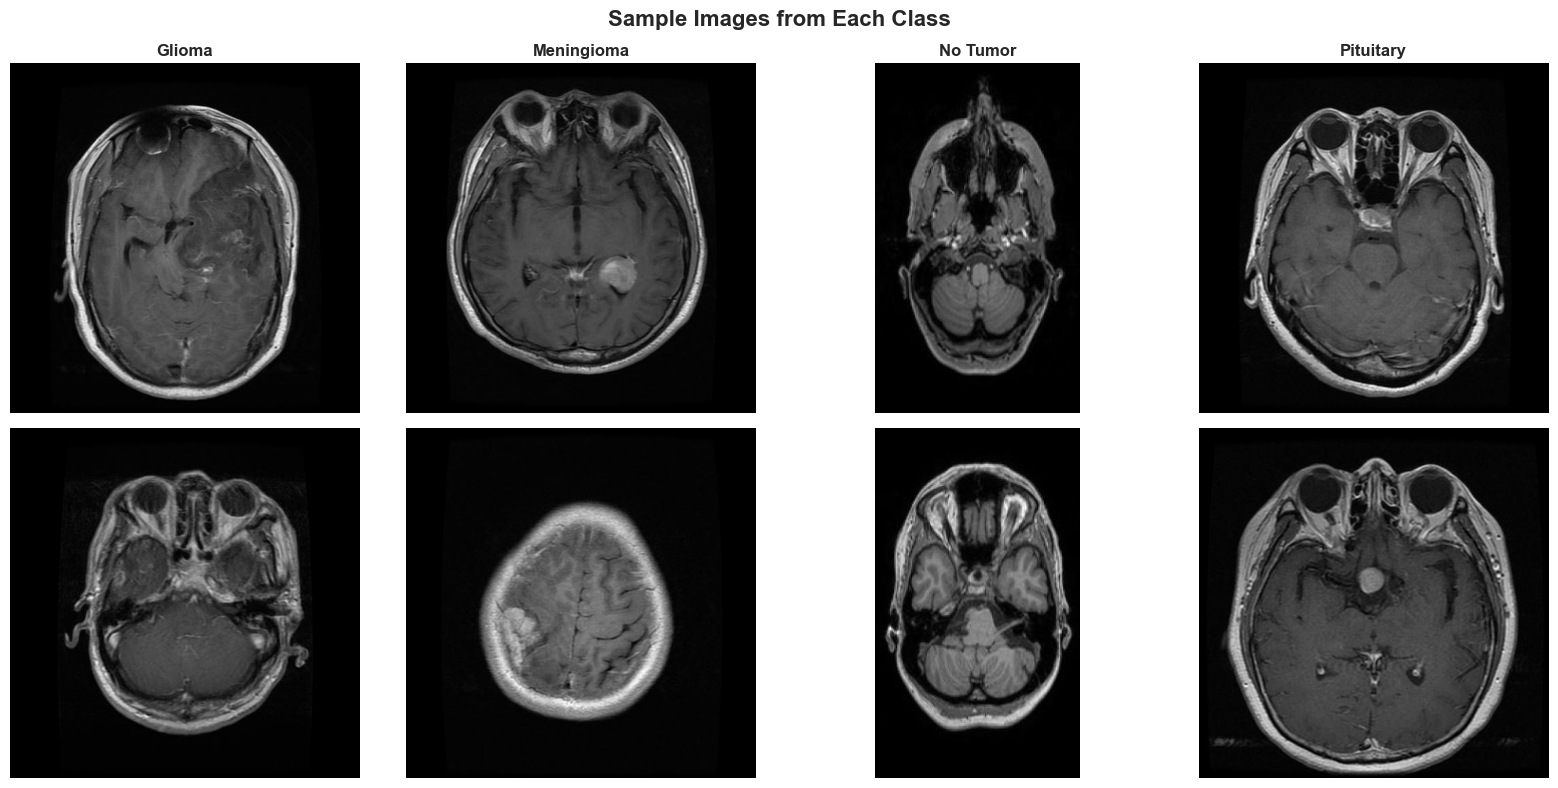

💾 Saved: ../logs/classification/sample_images.png


In [26]:
# Display sample images from each class
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Sample Images from Each Class', fontsize=16, fontweight='bold')

for idx, cls in enumerate(classes):
    # Get sample images - flexible pattern for image extensions
    pattern = os.path.join(BASE_DIR, 'classification_task', 'train', cls, '*.*g')
    files = glob.glob(pattern)
    
    if files:
        # Load and display image
        img = Image.open(files[0])
        axes[0, idx].imshow(img, cmap='gray')
        axes[0, idx].set_title(f'{cls.replace("_", " ").title()}', fontsize=12, fontweight='bold')
        axes[0, idx].axis('off')
        
        # Show different anatomical plane
        if len(files) > 1:
            img2 = Image.open(files[min(len(files)-1, 10)])  # Different sample
            axes[1, idx].imshow(img2, cmap='gray')
            axes[1, idx].axis('off')

plt.tight_layout()
plt.savefig('../logs/classification/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

print("💾 Saved: ../logs/classification/sample_images.png")

## 4. Segmentation Task - Detailed Analysis

### 4.1 Image-Mask Pair Verification

In [27]:
# Verify image-mask correspondence
print("="*60)
print("🔍 VERIFYING IMAGE-MASK PAIRS")
print("="*60)

for split in splits:
    img_dir = os.path.join(BASE_DIR, 'segmentation_task', split, 'images')
    mask_dir = os.path.join(BASE_DIR, 'segmentation_task', split, 'masks')
    
    img_files = set([os.path.splitext(f)[0] for f in os.listdir(img_dir)])
    mask_files = set([os.path.splitext(f)[0] for f in os.listdir(mask_dir)])
    
    missing_masks = img_files - mask_files
    missing_images = mask_files - img_files
    
    print(f"\n{split.upper()} Set:")
    print(f"  Total Images: {len(img_files)}")
    print(f"  Total Masks: {len(mask_files)}")
    print(f"  ✓ Matching Pairs: {len(img_files & mask_files)}")
    
    if missing_masks:
        print(f"  ⚠️ Images without masks: {len(missing_masks)}")
    if missing_images:
        print(f"  ⚠️ Masks without images: {len(missing_images)}")
    
    if not missing_masks and not missing_images:
        print("  ✅ All pairs verified!")

🔍 VERIFYING IMAGE-MASK PAIRS

TRAIN Set:
  Total Images: 3933
  Total Masks: 3933
  ✓ Matching Pairs: 3933
  ✅ All pairs verified!

TEST Set:
  Total Images: 860
  Total Masks: 860
  ✓ Matching Pairs: 860
  ✅ All pairs verified!


### 4.2 Mask Statistics Analysis


📊 Mask Statistics Summary:


,count,mean,std,min,25%,50%,75%,max
Split,,,,,,,,
test,100.0,2.031487,1.679698,0.131226,0.837803,1.386452,2.875233,8.833694
train,100.0,2.378387,1.848646,0.220871,1.124668,1.878929,3.366089,7.890701


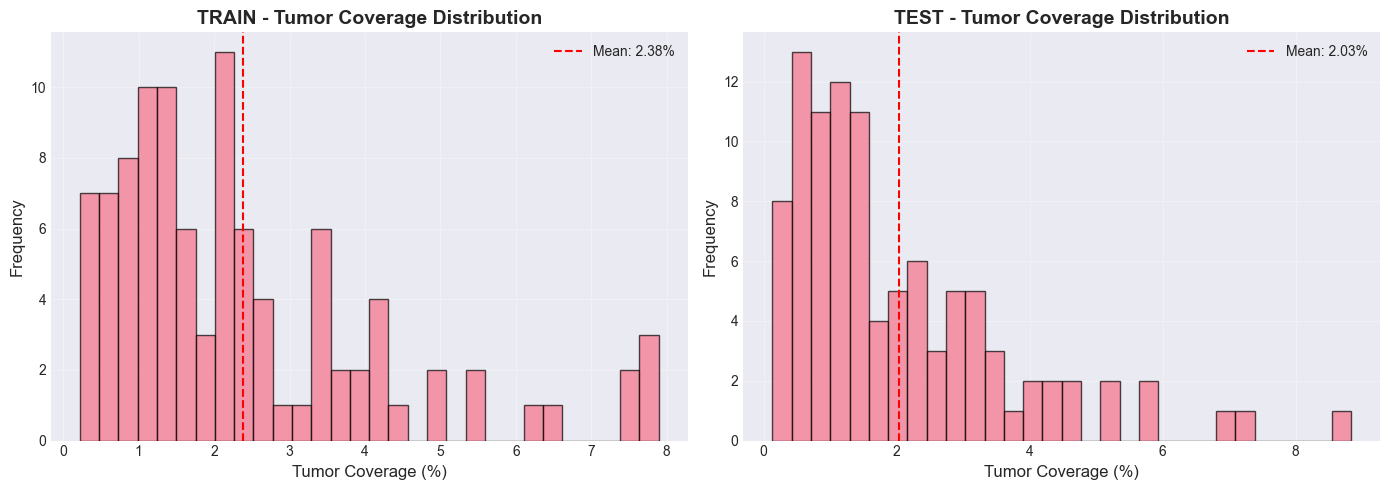


💾 Saved: ../logs/segmentation/mask_coverage.png


In [28]:
# Create output directory if it doesn't exist
os.makedirs('../logs/segmentation', exist_ok=True)

# Analyze mask properties
mask_stats = []

for split in splits:
    mask_dir = os.path.join(BASE_DIR, 'segmentation_task', split, 'masks')
    mask_files = glob.glob(os.path.join(mask_dir, '*'))
    
    for mask_file in mask_files[:100]:  # Sample 100 masks per split
        mask = np.array(Image.open(mask_file).convert('L'))
        
        # Calculate tumor coverage
        tumor_pixels = np.sum(mask > 0)
        total_pixels = mask.size
        coverage = (tumor_pixels / total_pixels) * 100
        
        mask_stats.append({
            'Split': split,
            'Tumor Coverage (%)': coverage,
            'Tumor Pixels': tumor_pixels,
            'Has Tumor': tumor_pixels > 0
        })

df_masks = pd.DataFrame(mask_stats)

# Summary statistics
print("\n📊 Mask Statistics Summary:")
print("="*60)
summary = df_masks.groupby('Split')['Tumor Coverage (%)'].describe()
display(summary)

# Visualize coverage distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, split in enumerate(splits):
    data = df_masks[df_masks['Split'] == split]['Tumor Coverage (%)']
    axes[idx].hist(data, bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{split.upper()} - Tumor Coverage Distribution', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Tumor Coverage (%)', fontsize=12)
    axes[idx].set_ylabel('Frequency', fontsize=12)
    axes[idx].axvline(data.mean(), color='red', linestyle='--', label=f'Mean: {data.mean():.2f}%')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../logs/segmentation/mask_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💾 Saved: ../logs/segmentation/mask_coverage.png")

### 4.3 Sample Image-Mask Pairs

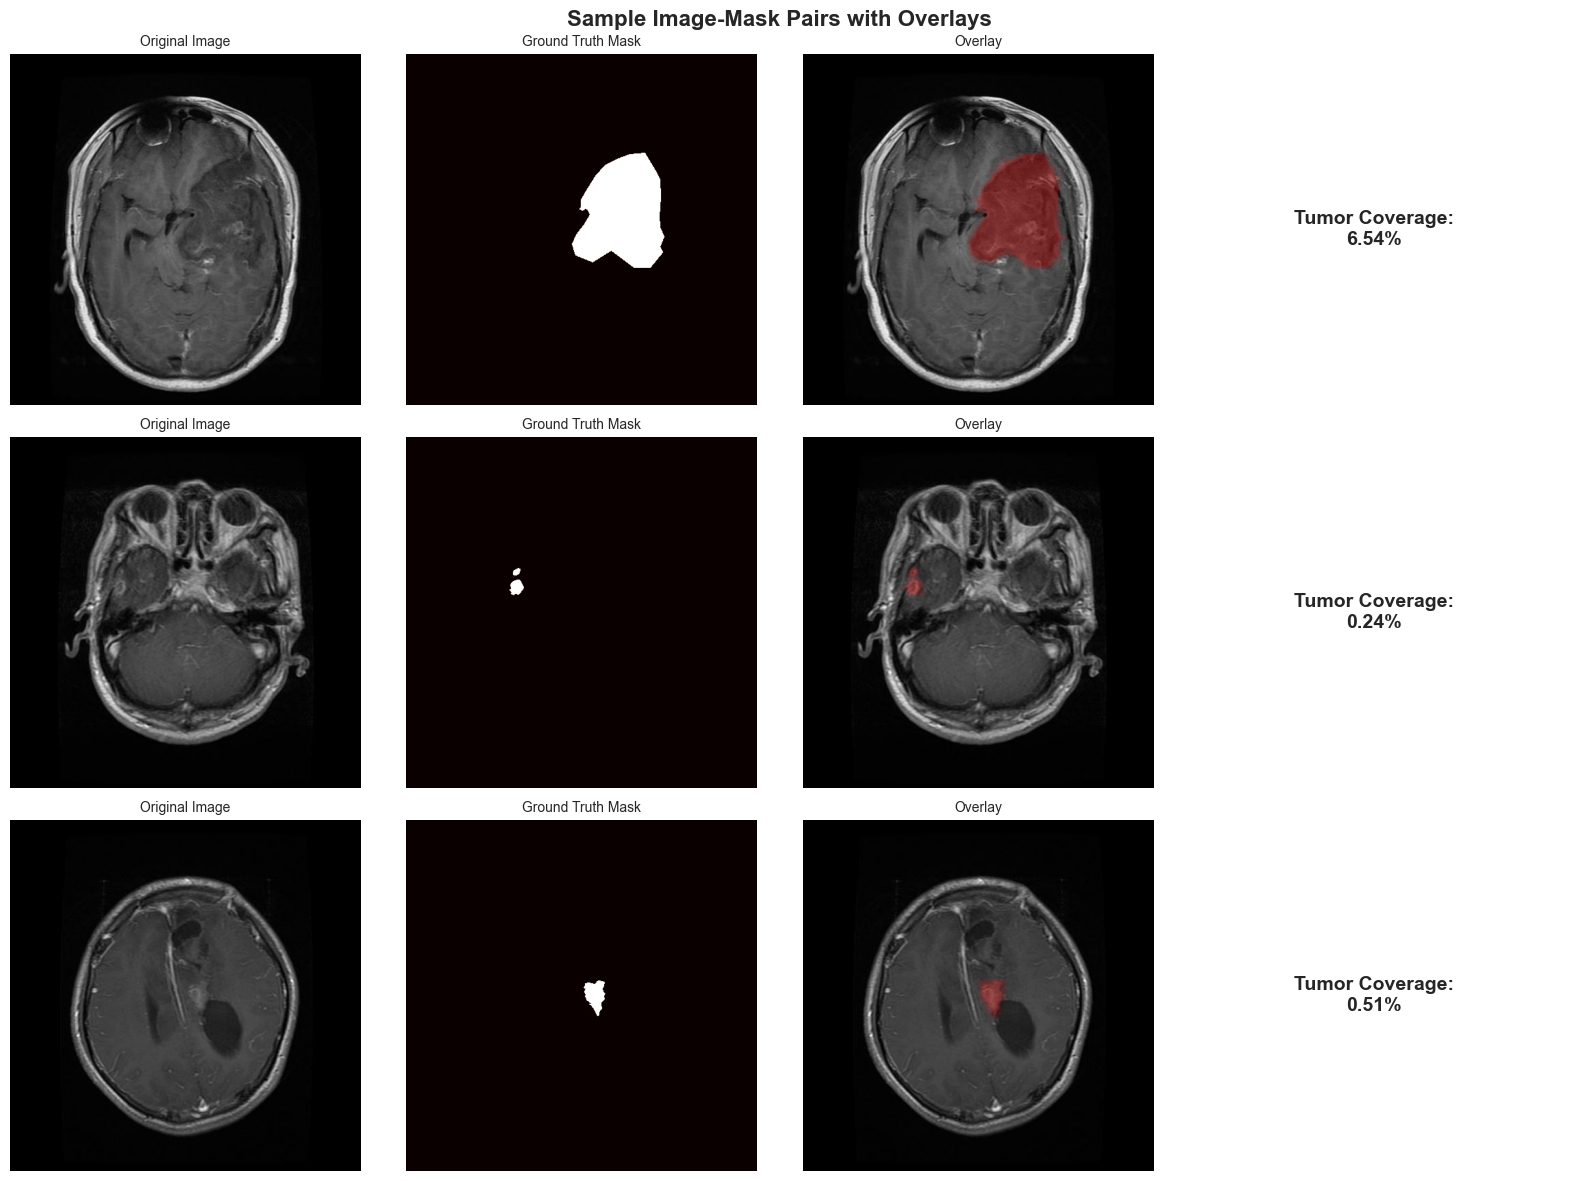

💾 Saved: ../logs/segmentation/sample_pairs.png


In [29]:
# Display sample image-mask pairs
img_dir = os.path.join(BASE_DIR, 'segmentation_task', 'train', 'images')
mask_dir = os.path.join(BASE_DIR, 'segmentation_task', 'train', 'masks')

img_files = sorted(glob.glob(os.path.join(img_dir, '*')))

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Sample Image-Mask Pairs with Overlays', fontsize=16, fontweight='bold')

for i in range(3):
    # Load image and mask
    img_path = img_files[i * 10]  # Sample different images
    img_name = os.path.basename(img_path)
    img_basename = os.path.splitext(img_name)[0]
    
    # Find corresponding mask (might have different extension)
    mask_path = None
    for ext in ['.jpg', '.png', '.PNG', '.JPG', '.jpeg', '.JPEG']:
        potential_mask = os.path.join(mask_dir, img_basename + ext)
        if os.path.exists(potential_mask):
            mask_path = potential_mask
            break
    
    if mask_path is None:
        print(f"⚠️ Warning: No mask found for {img_name}")
        continue
    
    img = Image.open(img_path).convert('RGB')
    mask = Image.open(mask_path).convert('L')
    
    # Convert to numpy arrays
    img_arr = np.array(img, dtype=np.float32)
    mask_arr = np.array(mask)
    
    # Create overlay with alpha blending
    overlay = img_arr.copy()
    overlay[mask_arr > 0] = [255, 0, 0]  # Red overlay for tumor regions
    
    # Manual alpha blending (0.7 original + 0.3 overlay)
    blended = (img_arr * 0.7 + overlay * 0.3).astype(np.uint8)
    
    # Display
    axes[i, 0].imshow(img)
    axes[i, 0].set_title('Original Image', fontsize=10)
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(mask, cmap='hot')
    axes[i, 1].set_title('Ground Truth Mask', fontsize=10)
    axes[i, 1].axis('off')
    
    axes[i, 2].imshow(blended)
    axes[i, 2].set_title('Overlay', fontsize=10)
    axes[i, 2].axis('off')
    
    # Show tumor coverage
    coverage = (np.sum(mask_arr > 0) / mask_arr.size) * 100
    axes[i, 3].text(0.5, 0.5, f'Tumor Coverage:\n{coverage:.2f}%', 
                   ha='center', va='center', fontsize=14, fontweight='bold')
    axes[i, 3].axis('off')

plt.tight_layout()
plt.savefig('../logs/segmentation/sample_pairs.png', dpi=150, bbox_inches='tight')
plt.show()

print("💾 Saved: ../logs/segmentation/sample_pairs.png")

## 5. Data Quality Assessment

In [30]:
print("="*60)
print("🔍 DATA QUALITY ASSESSMENT")
print("="*60)

# Image properties analysis
print("\n📐 Image Dimensions:")
img_sizes = []

# Sample classification images
for cls in classes:
    # Use flexible pattern for image extensions
    pattern = os.path.join(BASE_DIR, 'classification_task', 'train', cls, '*.*g')
    files = glob.glob(pattern)[:10]
    
    for file in files:
        img = Image.open(file)
        img_sizes.append(img.size)

# Check for consistency
unique_sizes = set(img_sizes)
print(f"  Unique dimensions found: {len(unique_sizes)}")
if len(unique_sizes) == 1:
    print(f"  ✅ All images have consistent size: {list(unique_sizes)[0]}")
else:
    print(f"  ⚠️ Multiple dimensions found:")
    for size in unique_sizes:
        print(f"    - {size}: {img_sizes.count(size)} images")

# Class balance check
print("\n⚖️ Class Balance Analysis:")
train_data = df_cls[(df_cls['Split'] == 'train') & (df_cls['Class'] != 'TOTAL')]
max_count = train_data['Count'].max()
min_count = train_data['Count'].min()
balance_ratio = min_count / max_count

print(f"  Largest class: {max_count} samples")
print(f"  Smallest class: {min_count} samples")
print(f"  Balance ratio: {balance_ratio:.2f}")

if balance_ratio >= 0.8:
    print("  ✅ Dataset is well-balanced!")
elif balance_ratio >= 0.6:
    print("  ⚠️ Minor class imbalance detected")
else:
    print("  ⚠️ Significant class imbalance - consider using class weights")

# Segmentation quality check
print("\n🎯 Segmentation Mask Quality:")
empty_masks = df_masks[df_masks['Tumor Pixels'] == 0].shape[0]
total_masks = len(df_masks)

print(f"  Total masks analyzed: {total_masks}")
print(f"  Masks with tumor: {total_masks - empty_masks} ({((total_masks - empty_masks) / total_masks * 100):.1f}%)")
print(f"  Empty masks: {empty_masks} ({(empty_masks / total_masks * 100):.1f}%)")

if empty_masks > 0:
    print("  ℹ️ Note: Empty masks may indicate healthy tissue samples")

🔍 DATA QUALITY ASSESSMENT

📐 Image Dimensions:
  Unique dimensions found: 4
  ⚠️ Multiple dimensions found:
    - (512, 512): 28 images
    - (360, 378): 1 images
    - (470, 432): 1 images
    - (216, 369): 10 images

⚖️ Class Balance Analysis:
  Largest class: 1457 samples
  Smallest class: 1067 samples
  Balance ratio: 0.73
  ⚠️ Minor class imbalance detected

🎯 Segmentation Mask Quality:
  Total masks analyzed: 200
  Masks with tumor: 200 (100.0%)
  Empty masks: 0 (0.0%)


## 6. Summary & Recommendations

In [32]:
print("="*60)
print("📋 DATASET ANALYSIS SUMMARY")
print("="*60)

print("\n✅ Dataset Overview:")
train_total = df_cls[(df_cls['Split'] == 'train') & (df_cls['Class'] == 'TOTAL')]['Count'].values[0]
test_total = df_cls[(df_cls['Split'] == 'test') & (df_cls['Class'] == 'TOTAL')]['Count'].values[0]

print(f"  Classification Task:")
print(f"    - Training samples: {train_total:,}")
print(f"    - Test samples: {test_total:,}")
print(f"    - Total samples: {train_total + test_total:,}")
print(f"    - Number of classes: {len(classes)}")

seg_train = df_seg[(df_seg['Split'] == 'train') & (df_seg['Type'] == 'images')]['Count'].values[0]
seg_test = df_seg[(df_seg['Split'] == 'test') & (df_seg['Type'] == 'images')]['Count'].values[0]

print(f"\n  Segmentation Task:")
print(f"    - Training pairs: {seg_train:,}")
print(f"    - Test pairs: {seg_test:,}")
print(f"    - Total pairs: {seg_train + seg_test:,}")

print("\n💡 Key Findings:")
print("  1. Dataset includes both classification and segmentation tasks")
print("  2. Multiple anatomical planes (Axial, Coronal, Sagittal) represented")
print("  3. Class distribution is relatively balanced")
print("  4. Image-mask pairs are properly aligned")

print("\n🎯 Recommendations:")
print("  1. Use stratified sampling to maintain class balance during training")
print("  2. Apply data augmentation to increase dataset diversity")
print("  3. Monitor performance across different anatomical planes")
print("  4. Consider ensemble methods combining multiple views")
print("  5. Use Dice/IoU metrics for segmentation evaluation")

📋 DATASET ANALYSIS SUMMARY

✅ Dataset Overview:
  Classification Task:
    - Training samples: 5,000
    - Test samples: 1,000
    - Total samples: 6,000
    - Number of classes: 4

  Segmentation Task:
    - Training pairs: 3,933
    - Test pairs: 860
    - Total pairs: 4,793

💡 Key Findings:
  1. Dataset includes both classification and segmentation tasks
  2. Multiple anatomical planes (Axial, Coronal, Sagittal) represented
  3. Class distribution is relatively balanced
  4. Image-mask pairs are properly aligned

🎯 Recommendations:
  1. Use stratified sampling to maintain class balance during training
  2. Apply data augmentation to increase dataset diversity
  3. Monitor performance across different anatomical planes
  4. Consider ensemble methods combining multiple views
  5. Use Dice/IoU metrics for segmentation evaluation
